In [41]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [67]:
path = "boyaNautilus/"
filename = "Nautilus Data.xlsx"

dtype_dict = {
    "Device": str,  # Adjust with your actual column names
    "Date": str,
    "Data": str,
    "Depth": float,
    "OD": float,
    "EC": float,
    "Temp": float,
    "Chlor": float,
    "Batt12": float,
    "Batt13": float,
}

dataframes = pd.read_excel(os.path.join(path, filename), sheet_name=None, skiprows=1, dtype=dtype_dict)

for sheet_name, df in dataframes.items():
    if 'Time' in df.columns:
        df.rename(columns={'Time': 'Date'}, inplace=True)

In [68]:
dataframes.keys()

dict_keys(['Sur', 'Urrutias', 'Ribera', 'EntreIslas', 'Pedruchillo', 'Albujon', 'Narejos', 'Nietos'])

In [70]:
dataframes["Albujon"]

,Device,Date,Data,Depth,OD,EC,Temp,Chlor,Batt12,Batt3
0,2A0D0C7,2024-11-28 07:38:29,045207513d13115a00458c27,4.82,7.81,61.19,17.9,0.69,140.0,3.9
1,2A0D0C7,2024-11-28 07:37:21,0452074f3d22115a0045ce27,4.82,7.79,61.34,17.9,0.69,206.0,3.9
2,2A0D0C7,2024-11-28 07:36:12,045207503d1d115a00451027,4.82,7.80,61.29,17.9,0.69,16.0,3.9
3,2A0D0C7,2024-11-28 07:35:03,044d07514020115a00455127,4.77,7.81,64.32,17.9,0.69,81.0,3.9
4,2A0D0C7,2024-11-28 01:29:30,045107503e41120a00457a27,4.81,7.80,62.65,18.1,0.69,122.0,3.9
...,...,...,...,...,...,...,...,...,...,...
2601,1B29632,2024-04-09 17:26:24,004d09074d1513280003a728,0.77,9.70,77.21,19.4,0.30,167.0,4.0
2602,1B29632,2024-04-09 17:25:54,01390906460513280003c228,1.57,9.60,70.50,19.4,0.30,194.0,4.0
2603,1B29632,2024-04-09 17:25:24,02390907443c13280004de28,2.57,9.70,68.60,19.4,0.40,222.0,4.0
2604,1B29632,2024-04-09 17:24:55,0338090a431113280004fb28,3.56,9.10,67.17,19.4,0.40,251.0,4.0


In [71]:
def remove_outliers(df):
    """Remove outliers from a dataframe using IQR."""
    # Select only numeric columns
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    for col in numeric_cols:
        # Calculate Q1, Q3, and IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define the outlier range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filter out outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df

# Apply the function to all dataframes in the dictionary
cleaned_dataframes = {key: remove_outliers(df) for key, df in dataframes.items()}


In [72]:
def replace_zeros_and_interpolate(df):
    """Replace zeros with NaN and perform linear interpolation."""
    # Replace zeros with NaN
    df.replace(0, np.nan, inplace=True)
    
    # Perform linear interpolation
    df.interpolate(method='linear', inplace=True)
    
    return df

# Apply to all dataframes in the dictionary
interpolated_dataframes = {key: replace_zeros_and_interpolate(df.copy()) for key, df in cleaned_dataframes.items()}


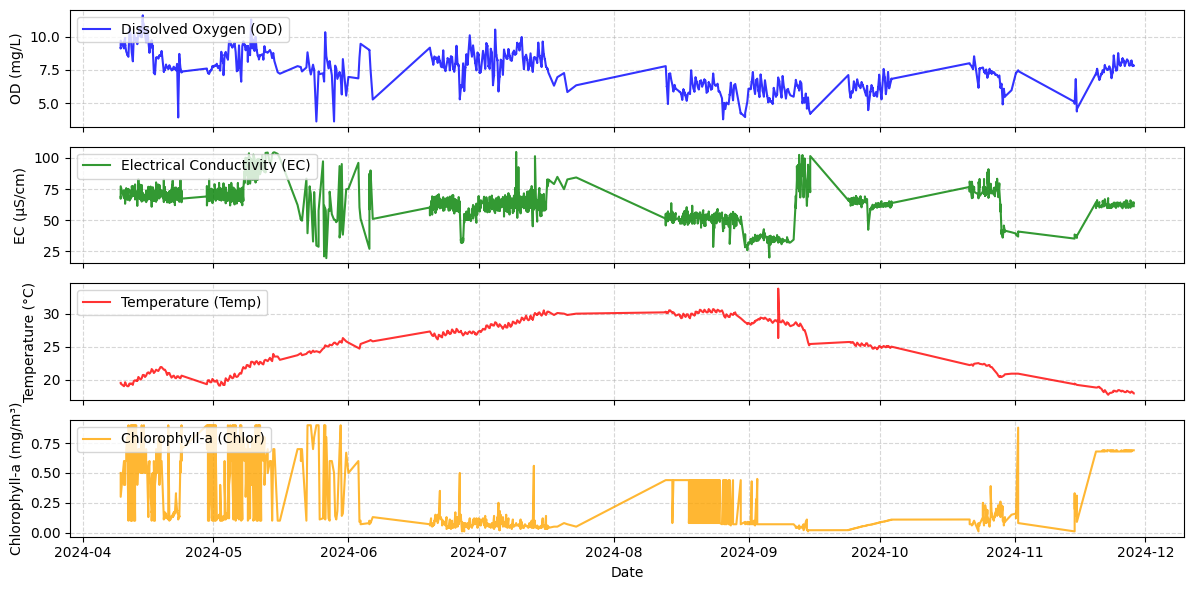

In [63]:

# Select one dataframe from the dictionary
df = interpolated_dataframes["Albujon"]

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
ec_idx = 1
temp_idx = 2
chlor_idx = 3

# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

# Plot OD
axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen (OD)', color='blue', alpha=0.8)
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

# Plot EC
axes[ec_idx].plot(df.index, df['EC'], label='Electrical Conductivity (EC)', color='green', alpha=0.8)
axes[ec_idx].set_ylabel('EC (µS/cm)')
axes[ec_idx].legend(loc='upper left')
axes[ec_idx].grid(True, linestyle='--', alpha=0.5)

# Plot Temp
axes[temp_idx].plot(df.index, df['Temp'], label='Temperature (Temp)', color='red', alpha=0.8)
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

# Plot Chlor
axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a (Chlor)', color='orange', alpha=0.8)
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()


In [73]:
interpolated_dataframes["Albujon"]

,Device,Date,Data,Depth,OD,EC,Temp,Chlor,Batt12,Batt3
0,2A0D0C7,2024-11-28 07:38:29,045207513d13115a00458c27,4.82,7.81,61.19,17.9,0.69,140.0,3.9
1,2A0D0C7,2024-11-28 07:37:21,0452074f3d22115a0045ce27,4.82,7.79,61.34,17.9,0.69,206.0,3.9
2,2A0D0C7,2024-11-28 07:36:12,045207503d1d115a00451027,4.82,7.80,61.29,17.9,0.69,16.0,3.9
3,2A0D0C7,2024-11-28 07:35:03,044d07514020115a00455127,4.77,7.81,64.32,17.9,0.69,81.0,3.9
4,2A0D0C7,2024-11-28 01:29:30,045107503e41120a00457a27,4.81,7.80,62.65,18.1,0.69,122.0,3.9
...,...,...,...,...,...,...,...,...,...,...
2601,1B29632,2024-04-09 17:26:24,004d09074d1513280003a728,0.77,9.70,77.21,19.4,0.30,167.0,4.0
2602,1B29632,2024-04-09 17:25:54,01390906460513280003c228,1.57,9.60,70.50,19.4,0.30,194.0,4.0
2603,1B29632,2024-04-09 17:25:24,02390907443c13280004de28,2.57,9.70,68.60,19.4,0.40,222.0,4.0
2604,1B29632,2024-04-09 17:24:55,0338090a431113280004fb28,3.56,9.10,67.17,19.4,0.40,251.0,4.0


In [74]:
def summarize_dataframes(dataframes, columns):
    summary = {}
    for key, df in dataframes.items():
        if all(col in df.columns for col in columns):  # Ensure the required columns exist
            date_range = (df["Date"].min(), df["Date"].max())
            stats = {
                "Date Range": date_range,
                "Mean": round(df[columns].mean(), 2).to_dict(),
                "Min": df[columns].min().to_dict(),
                "Max": df[columns].max().to_dict(),
            }
            summary[key] = stats
    return summary

# Specify the columns of interest
columns_of_interest = ["OD", "EC", "Temp", "Chlor"]

# Call the function
summary_dict = summarize_dataframes(interpolated_dataframes, columns_of_interest)

# Display the summary for each dataframe
for key, stats in summary_dict.items():
    print(f"Summary for {key}:")
    print(f"  Date Range: {stats['Date Range']}")
    print(f"  Mean: {stats['Mean']}")
    print(f"  Min: {stats['Min']}")
    print(f"  Max: {stats['Max']}")
    print()


Summary for Sur:
  Date Range: (Timestamp('2022-09-21 17:33:14'), Timestamp('2024-11-28 07:19:48'))
  Mean: {'OD': 7.61, 'EC': 61.93, 'Temp': 21.23, 'Chlor': 0.25}
  Min: {'OD': 3.52, 'EC': 0.61, 'Temp': 10.1, 'Chlor': 0.01}
  Max: {'OD': 11.61, 'EC': 155.18, 'Temp': 31.5, 'Chlor': 0.94}

Summary for Urrutias:
  Date Range: (Timestamp('2022-09-21 14:26:27'), Timestamp('2024-11-28 05:47:02'))
  Mean: {'OD': 7.47, 'EC': 62.63, 'Temp': 20.19, 'Chlor': 0.28}
  Min: {'OD': 2.31, 'EC': 2.87, 'Temp': 10.7, 'Chlor': 0.01}
  Max: {'OD': 11.97, 'EC': 157.41, 'Temp': 31.4, 'Chlor': 0.91}

Summary for Ribera:
  Date Range: (Timestamp('2022-09-21 14:25:20'), Timestamp('2024-11-28 09:20:22'))
  Mean: {'OD': 7.42, 'EC': 62.79, 'Temp': 22.89, 'Chlor': 0.3}
  Min: {'OD': 3.53, 'EC': 28.57, 'Temp': 10.5, 'Chlor': 0.01}
  Max: {'OD': 11.26, 'EC': 89.11, 'Temp': 32.3, 'Chlor': 0.75}

Summary for EntreIslas:
  Date Range: (Timestamp('2022-10-14 16:11:51'), Timestamp('2024-11-27 10:39:17'))
  Mean: {'OD': 7

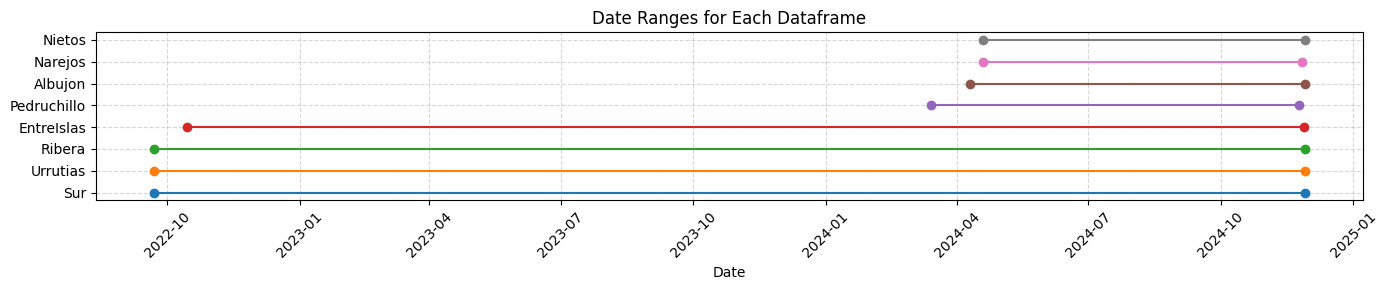

In [78]:
for key, df in interpolated_dataframes.items():
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])  # Convert to datetime if not already

def plot_date_ranges(dataframes):
    fig, ax = plt.subplots(figsize=(14, 3))
    for i, (key, df) in enumerate(dataframes.items()):
        if "Date" in df.columns:
            date_min = df["Date"].min()
            date_max = df["Date"].max()
            ax.plot([date_min, date_max], [i, i], label=key, marker='o')  # Plot a line with markers
            #ax.text(date_min, i, f" {date_min.date()}", va='center', fontsize=8)  # Add start date
            #ax.text(date_max, i, f" {date_max.date()}", va='center', fontsize=8)  # Add end date

    ax.set_yticks(range(len(dataframes)))
    ax.set_yticklabels(dataframes.keys())
    ax.set_xlabel("Date")
    ax.set_title("Date Ranges for Each Dataframe")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    #plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function
plot_date_ranges(interpolated_dataframes)

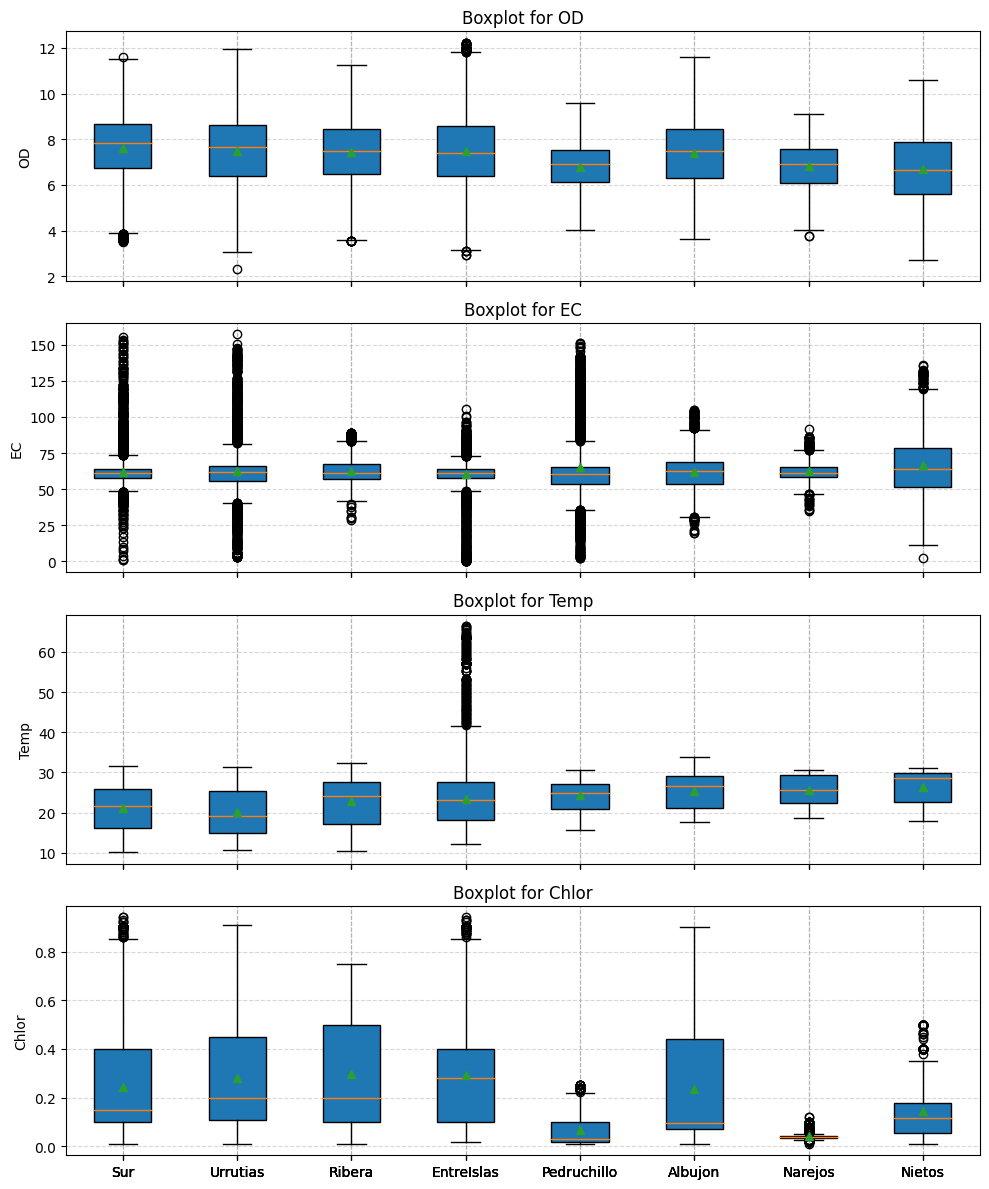

In [81]:
columns_of_interest = ["OD", "EC", "Temp", "Chlor"]

# Prepare data for each column
def prepare_boxplot_data(dataframes, column):
    data = []
    labels = []
    for key, df in dataframes.items():
        if column in df.columns:
            data.append(df[column].dropna())  # Drop NaN values
            labels.append(key)  # Use dataframe key as the label
    return data, labels

# Create boxplots for each column
fig, axes = plt.subplots(len(columns_of_interest), 1, figsize=(10, 3 * len(columns_of_interest)), sharex=True)

for i, column in enumerate(columns_of_interest):
    data, labels = prepare_boxplot_data(interpolated_dataframes, column)
    axes[i].boxplot(data, labels=labels, patch_artist=True, showmeans=True)
    axes[i].set_title(f"Boxplot for {column}")
    axes[i].set_ylabel(column)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()